# Weight sensitivity — Prong B (w mixture perturbation)

Perturbs expert **w** (OSM / CORINE / population / … weights inside each group’s **S**), renormalises **W^(g)**, then fuses with **fixed α**.

Requires `build_and_export` bundles that include `mix` term rasters in `groups_manifest.yaml` (re-export after code update).

Loads from `Output/Proxy_diagnostics/W_groups/`.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml

REPO = Path.cwd()
if not (REPO / "proxy").is_dir():
    REPO = Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from proxy.diagnostics.weight_sensitivity.load_exports import bundle_path, load_bundle
from proxy.diagnostics.weight_sensitivity.cell_metrics import tv_per_cell_all

def load_rep_bundle(role: str):
    rep = CFG["representative_sectors"][role]
    sk = rep["sector_key"]
    data = load_bundle(bundle_path(EXPORT_ROOT, sk, COUNTRY_TAG, YEAR))
    if not data.get("has_mix"):
        raise ValueError(f"{sk}: bundle has no mix terms — re-run build_and_export")
    pix = pick_pollutant_index(data["alpha"], rep["primary_pollutant"])
    return sk, data, pix
from proxy.diagnostics.weight_sensitivity.prong_b_core import (
    fuse_alpha_stack,
    pick_pollutant_index,
    crop_cell_patch,
)
from proxy.diagnostics.weight_sensitivity.prong_w_core import (
    prepare_w2_state,
    run_w2_all_representatives,
    run_w2_on_state,
    perturb_weight,
    stack_from_mix,
)
from proxy.core import log
log.configure("INFO")

CFG_PATH = REPO / "proxy" / "config" / "weight_sensitivity_prong_b.yaml"
with CFG_PATH.open(encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

def _export_root(repo: Path) -> Path:
    for name in ("Output", "OUTPUT"):
        p = repo / name / "Proxy_diagnostics" / "W_groups"
        if p.is_dir():
            return p
    return repo / "OUTPUT" / "Proxy_diagnostics" / "W_groups"

EXPORT_ROOT = _export_root(REPO)
COUNTRY_TAG = "Greece"
YEAR = 2019
FIG_DIR = REPO / "Output" / "Proxy_diagnostics" / "figures" / "prong_b_w"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
summaries = run_w2_all_representatives(EXPORT_ROOT, REPO, CFG, COUNTRY_TAG, YEAR)
(FIG_DIR / "b2_summary.json").write_text(json.dumps(summaries, indent=2), encoding="utf-8")
summaries


Prong B role=low sector=A_PublicPower
Prong B: computing sensitive cells (no prong_a summary.json)
Prong B A_PublicPower primary: fuse baseline W0 (1 groups)
Prong B A_PublicPower primary: perturb 4/4
Prong B role=high sector=B_Industry
Prong B: loaded 615 sensitive cells from prong_a summary
Prong B B_Industry primary: fuse baseline W0 (4 groups)
Prong B B_Industry primary: perturb 4/16
Prong B B_Industry primary: perturb 8/16
Prong B B_Industry primary: perturb 12/16
Prong B B_Industry primary: perturb 16/16
Prong B B_Industry contrast: fuse baseline W0 (4 groups)
Prong B B_Industry contrast: perturb 4/16
Prong B B_Industry contrast: perturb 8/16
Prong B B_Industry contrast: perturb 12/16
Prong B B_Industry contrast: perturb 16/16
Prong B role=mid sector=J_Waste
Prong B: loaded 3354 sensitive cells from prong_a summary
Prong B J_Waste primary: fuse baseline W0 (3 groups)
Prong B J_Waste primary: perturb 4/12
Prong B J_Waste primary: perturb 8/12
Prong B J_Waste primary: perturb 12/12

2152

Prong B: loaded 615 sensitive cells from prong_a summary


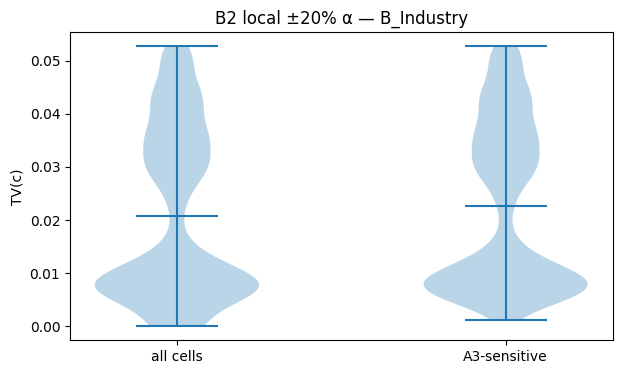

In [3]:
# B2 violin: TV under local w perturb (high sector, alpha fixed)
from copy import deepcopy

from proxy.diagnostics.weight_sensitivity.prong_w_core import (
    perturb_keys_for_mixer,
    perturb_weight,
    stack_from_mix,
)

sk, data, pix = load_rep_bundle("high")
state = prepare_w2_state(data)
mat = np.asarray(state["alpha_doc"]["alpha"], dtype=np.float32)
alpha_row = mat[pix] if mat.size else np.ones(len(state["group_names"]), dtype=np.float32) / len(
    state["group_names"]
)
cell_id, valid, fid, nb = state["cell_id"], state["valid"], state["fid"], state["nb"]
sensitive, cids = state["sensitive"], state["cids"]
W0 = fuse_alpha_stack(state["stack"], alpha_row, cell_id, valid, fid, nb)

tv_all, tv_sens = [], []
pct = 0.2
for gname in state["group_names"]:
    spec = state["mix_by_group"][gname]
    mixer = str(spec["mixer"])
    for wkey in perturb_keys_for_mixer(mixer):
        for sign in (-1, 1):
            mix_p = deepcopy(state["mix_by_group"])
            mix_p[gname] = deepcopy(spec)
            mix_p[gname]["weights"] = perturb_weight(spec["weights"], wkey, pct, sign, mixer)
            stack_p = stack_from_mix(mix_p, state["group_names"], cell_id, valid, fid, nb)
            Wp = fuse_alpha_stack(stack_p, alpha_row, cell_id, valid, fid, nb)
            tv_arr = tv_per_cell_all(W0, Wp, cell_id)
            for cid in cids:
                if cid >= tv_arr.size:
                    continue
                tv = float(tv_arr[cid])
                tv_all.append(tv)
                if cid in sensitive:
                    tv_sens.append(tv)

fig, ax = plt.subplots(figsize=(7, 4))
ax.violinplot([tv_all, tv_sens], positions=[1, 2], showmeans=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(["all cells", "mix-sensitive"])
ax.set_ylabel("TV(c)")
ax.set_title(f"B2 local +/-20% w — {data['manifest']['sector_key']}")
fig.savefig(FIG_DIR / "b2_violin_high.png", dpi=150)
plt.show()


Prong B: loaded 615 sensitive cells from prong_a summary


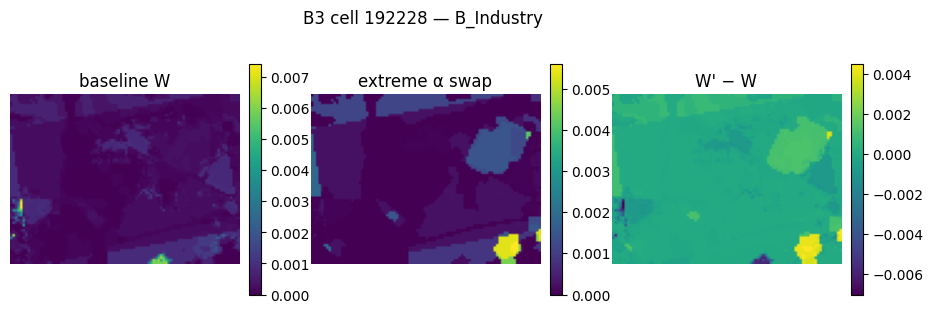

In [4]:
# B3 — mix-sensitive cell: baseline W vs w_osm +40% on first group
from copy import deepcopy

from proxy.diagnostics.weight_sensitivity.prong_w_core import perturb_weight, stack_from_mix

sk, data, pix = load_rep_bundle("high")
state = prepare_w2_state(data)
mat = np.asarray(state["alpha_doc"]["alpha"], dtype=np.float32)
alpha_row = mat[pix] if mat.size else np.ones(len(state["group_names"]), dtype=np.float32) / len(
    state["group_names"]
)
cell_id, valid, fid, nb = state["cell_id"], state["valid"], state["fid"], state["nb"]
nox, sens = state["nox"], state["sensitive"]
if not sens:
    raise RuntimeError("no mix-sensitive cells for B3")
best_cid = max(sens, key=lambda c: float(nox.get(c, 0.0)))

W0 = fuse_alpha_stack(state["stack"], alpha_row, cell_id, valid, fid, nb)
gname = state["group_names"][0]
spec = state["mix_by_group"][gname]
mix_p = deepcopy(state["mix_by_group"])
mix_p[gname] = deepcopy(spec)
mix_p[gname]["weights"] = perturb_weight(spec["weights"], "w_osm", 0.4, 1, str(spec["mixer"]))
stack_p = stack_from_mix(mix_p, state["group_names"], cell_id, valid, fid, nb)
W1 = fuse_alpha_stack(stack_p, alpha_row, cell_id, valid, fid, nb)

panels = [
    crop_cell_patch(W0, cell_id, best_cid),
    crop_cell_patch(W1, cell_id, best_cid),
    crop_cell_patch(W1 - W0, cell_id, best_cid),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, arr, title in zip(axes, panels, ["W baseline", "W w_osm +40%", "delta W"]):
    im = ax.imshow(arr, origin="upper")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"B3 cell {best_cid} — {sk} (alpha fixed)")
fig.savefig(FIG_DIR / "b3_case_study.png", dpi=150)
plt.show()


In [5]:
# B4 — elasticity dTV/dw (±20%, primary pollutant)
from copy import deepcopy

import pandas as pd

from proxy.diagnostics.weight_sensitivity.prong_w_core import (
    perturb_keys_for_mixer,
    perturb_weight,
    stack_from_mix,
)

rows = []
pct = 0.2
for role in ("low", "high", "mid"):
    sk, data, pix = load_rep_bundle(role)
    state = prepare_w2_state(data)
    mat = np.asarray(state["alpha_doc"]["alpha"], dtype=np.float32)
    g = len(state["group_names"])
    alpha_row = mat[pix] if mat.size else np.ones(g, dtype=np.float32) / float(g)
    cell_id, valid, fid, nb = state["cell_id"], state["valid"], state["fid"], state["nb"]
    cids = state["cids"]
    W0 = fuse_alpha_stack(state["stack"], alpha_row, cell_id, valid, fid, nb)
    for gname in state["group_names"]:
        spec = state["mix_by_group"][gname]
        mixer = str(spec["mixer"])
        for wkey in perturb_keys_for_mixer(mixer):
            mix_p = deepcopy(state["mix_by_group"])
            mix_p[gname] = deepcopy(spec)
            mix_p[gname]["weights"] = perturb_weight(spec["weights"], wkey, pct, 1, mixer)
            stack_p = stack_from_mix(mix_p, state["group_names"], cell_id, valid, fid, nb)
            Wp = fuse_alpha_stack(stack_p, alpha_row, cell_id, valid, fid, nb)
            tv_arr = tv_per_cell_all(W0, Wp, cell_id)
            tv = float(np.mean([tv_arr[c] for c in cids if c < tv_arr.size]))
            rows.append({"role": role, "sector": sk, "group": gname, "weight": wkey, "dTV_dw": tv / pct})

df = pd.DataFrame(rows)
display(df)
df.to_csv(FIG_DIR / "b4_elasticity.csv", index=False)


Prong B: computing sensitive cells (no prong_a summary.json)
Prong B: loaded 615 sensitive cells from prong_a summary
Prong B: loaded 3354 sensitive cells from prong_a summary


,role,sector,group,dTV_dalpha
0,high,B_Industry,refineries_petroleum,0.030484
1,high,B_Industry,manufacturing_combustion_residual,0.134198
2,high,B_Industry,mineral,0.175139
3,high,B_Industry,chemical_metal,0.044752
4,mid,J_Waste,solid_waste,0.163922
5,mid,J_Waste,wastewater,0.178100
6,mid,J_Waste,residual,0.025052
